**Experiment E** — effective-noise proxy (certified budget). Run Cell E0 first (it builds `results.csv` from the certified runs), then the figure cell.

In [1]:
# Cell E0 — Build results.csv for Experiment E from the per-experiment result files (certified budget).
# All rows come from the Poisson-sampling runs p{A,B,C}_results.csv (seed 0, the seven main methods).
# Looks for the files in ./results/, ./, or MyDrive/agptr_runs.
import os
import numpy as np
import pandas as pd

# Mount Google Drive (the training notebooks do this in their driver cell; Exp E needs it too)
try:
    from google.colab import drive as _gdrive
    if not os.path.isdir("/content/drive/MyDrive"):
        _gdrive.mount("/content/drive")
except Exception as _e:
    print("Google Drive not available (%s); looking for the files locally." % (_e,))

SEARCH = ["results", ".", "/content/drive/MyDrive/agptr_runs", "/content"]
def find(name):
    for d in SEARCH:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(name + " not found in " + str(SEARCH))

DATASETS = [("A", "Fashion-MNIST-IID"), ("B", "Fashion-MNIST-non-IID"), ("C", "CIFAR-10-IID")]
parts = []
for tag, ds in DATASETS:
    # Poisson-sampling runs: every method's seed-0 row is a new run in p{tag}_results.csv
    r = pd.read_csv(find(f"p{tag}_results.csv"))
    r = r[(r["status"] == "ok") & (r["seed"] == 0) & (r["source"] == "run") & (r["attack_key"] != "inball")
          & ~r["method"].isin(["PublicOnly", "AnchoredClip-NoGate", "DP-FedAvg+Public", "FLTrust", "FedVRDP-style", "FedVRDP-10ep"])]
    parts.append(r[["attack", "method", "f", "acc", "accept_rate"]].assign(Dataset=ds))
comb = pd.concat(parts).rename(columns={"attack": "Attack", "method": "Method", "f": "Percentage of Byzantine Cliets (%)",
                                        "acc": "Accuracy", "accept_rate": "Accept_Rate"})
comb = comb[["Dataset", "Attack", "Method", "Percentage of Byzantine Cliets (%)", "Accuracy", "Accept_Rate"]]
comb.to_csv("results.csv", index=False)
print("wrote results.csv:", len(comb), "rows;", "AG-PTR rows:", int((comb.Method == "AG-PTR").sum()))


Mounted at /content/drive
wrote results.csv: 882 rows; AG-PTR rows: 126


sigma_rel used: 1.0870887606480155


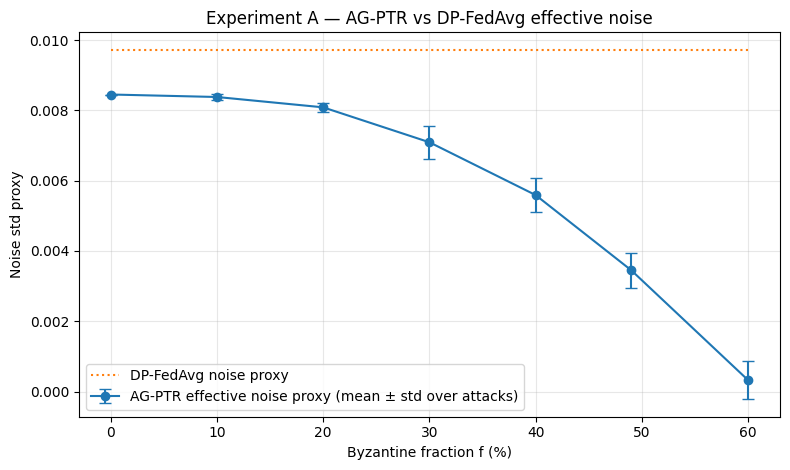

DP-FedAvg noise proxy = 0.009723217465539842
AG-PTR certified accepted-round noise proxy = 0.008696710085184125


,f,f_pct,noise_eff_mean,noise_eff_std
0,0.00,0.0,0.008452,0.000000
1,0.10,10.0,0.008381,0.000072
2,0.20,20.0,0.008087,0.000128
3,0.30,30.0,0.007093,0.000467
4,0.40,40.0,0.005591,0.000475
5,0.49,49.0,0.003451,0.000494
6,0.60,60.0,0.000324,0.000542


In [2]:
# Main figure — AG-PTR vs DP-FedAvg using effective noise proxy
# Input file: results.csv (built by Cell E0 from the certified runs)
# Dataset used: Fashion-MNIST-IID

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) Load results
# --------------------------------------------------
RESULTS_PATH = "results.csv"
if not os.path.exists(RESULTS_PATH):
    raise FileNotFoundError(f"Could not find {RESULTS_PATH}")

df_raw = pd.read_csv(RESULTS_PATH)

rename_map = {
    "Dataset": "dataset",
    "Attack": "attack",
    "Method": "method",
    "Percentage of Byzantine Cliets (%)": "f",
    "Accuracy": "acc",
    "Accept_Rate": "accept_rate",
}

missing = [c for c in rename_map if c not in df_raw.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

df = df_raw.rename(columns=rename_map).copy()

for col in ["dataset", "attack", "method"]:
    df[col] = df[col].astype(str).str.strip()

df["f"] = pd.to_numeric(df["f"], errors="coerce")
df["accept_rate"] = pd.to_numeric(df["accept_rate"], errors="coerce")

# --------------------------------------------------
# 2) Filter to original Experiment A dataset + AG-PTR
# --------------------------------------------------
DATASET_NAME = "Fashion-MNIST-IID"

ag = df[
    (df["dataset"] == DATASET_NAME) &
    (df["method"] == "AG-PTR")
].copy()

if len(ag) == 0:
    raise ValueError(f"No AG-PTR rows found for dataset={DATASET_NAME!r}")

# --------------------------------------------------
# 3) Constants from original Experiment A
# --------------------------------------------------
M = 100
C = 1.0
rho = 0.4
tau = 50

sigma_dp  = 0.9723217465539842                 # DP-FedAvg, certified eps = 2.0 (single release per round)
# AG-PTR, certified eps = 2.0 with the composed accountant: sigma_rel = (sqrt(5)/2) * sigma_dp = 1.0871.

sigma_rel = float(np.sqrt(5.0) / 2.0 * sigma_dp)
try:
    _cert = pd.read_csv([p for p in ["results/pA_results.csv", "pA_results.csv", "/content/drive/MyDrive/agptr_runs/pA_results.csv"] if os.path.exists(p)][0])
    sigma_rel = float(_cert[(_cert["method"] == "AG-PTR") & (_cert["sigma_mode"] == "certified")]["sigma_rel"].dropna().iloc[0])
except Exception:
    pass
print("sigma_rel used:", sigma_rel)

# DP-FedAvg constant noise proxy
dp_noise = sigma_dp * C / M

# AG-PTR certified accepted-round noise proxy
ag_noise_cert = sigma_rel * rho / tau

# AG-PTR effective noise proxy over all rounds
ag["accept_rate_filled"] = ag["accept_rate"].fillna(0.0)
ag["ag_noise_eff"] = np.sqrt(np.clip(ag["accept_rate_filled"].values, 1e-12, 1.0)) * ag_noise_cert
ag["f_pct"] = ag["f"] * 100.0

# Aggregate over attacks: mean ± std
agg = (
    ag.groupby("f", as_index=False)
      .agg(
          f_pct=("f_pct", "first"),
          noise_eff_mean=("ag_noise_eff", "mean"),
          noise_eff_std=("ag_noise_eff", "std"),
      )
      .sort_values("f")
      .reset_index(drop=True)
)

# --------------------------------------------------
# 4) Plot
# --------------------------------------------------
x = agg["f_pct"].values
x0, x1 = x.min(), x.max()

plt.figure(figsize=(8, 4.8))
plt.errorbar(
    x,
    agg["noise_eff_mean"],
    yerr=agg["noise_eff_std"],
    marker="o",
    capsize=4,
    label="AG-PTR effective noise proxy (mean ± std over attacks)"
)
plt.plot(
    [x0, x1],
    [dp_noise, dp_noise],
    linestyle=":",
    label="DP-FedAvg noise proxy"
)

plt.xlabel("Byzantine fraction f (%)")
plt.ylabel("Noise std proxy")
plt.title("Experiment A — AG-PTR vs DP-FedAvg effective noise")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("DP-FedAvg noise proxy =", dp_noise)
print("AG-PTR certified accepted-round noise proxy =", ag_noise_cert)
display(agg)